# Phase 6 - YOLO + OCR Pipeline

This notebook:
- loads your YOLO license plate detector
- detects the plate in an image
- crops the detected plate
- preprocesses the crop
- runs EasyOCR on the crop
- cleans the recognized plate text
- displays the full image, crop, and OCR result


In [1]:
# Run once if needed
# %pip install ultralytics easyocr opencv-python matplotlib pillow


In [2]:
from pathlib import Path
import re
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import easyocr


In [15]:
PROJECT_ROOT = Path().resolve()

YOLO_WEIGHTS = PROJECT_ROOT / "runs"/ "detect"/ "runs" / "plate_detector" /"weights"/ "best.pt"
IMAGE_PATH = PROJECT_ROOT / "test_image.jpg"

print("Project root:", PROJECT_ROOT)
print("YOLO weights exists:", YOLO_WEIGHTS.exists(), YOLO_WEIGHTS)
print("Image exists:", IMAGE_PATH.exists(), IMAGE_PATH)

# If your weights are elsewhere, uncomment and edit one of these:
# YOLO_WEIGHTS = PROJECT_ROOT / "runs" / "detect" / "train" / "weights" / "best.pt"
# YOLO_WEIGHTS = PROJECT_ROOT / "runs" / "detect" / "plate_detector" / "weights" / "best.pt"


Project root: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project
YOLO weights exists: True C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\runs\detect\runs\plate_detector\weights\best.pt
Image exists: True C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\test_image.jpg


In [16]:
model = YOLO(str(YOLO_WEIGHTS))

In [17]:
def clean_plate_text(text):
    text = text.upper()
    text = re.sub(r'[^A-Z0-9]', '', text)
    return text


def expand_box(x1, y1, x2, y2, img_w, img_h, pad_ratio=0.08):
    box_w = x2 - x1
    box_h = y2 - y1

    pad_x = int(box_w * pad_ratio)
    pad_y = int(box_h * pad_ratio)

    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(img_w, x2 + pad_x)
    y2 = min(img_h, y2 + pad_y)

    return x1, y1, x2, y2


def preprocess_plate_for_ocr(crop_bgr):
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresh


def detect_best_plate(image_bgr, model, conf=0.25):
    results = model.predict(source=image_bgr, conf=conf, verbose=False)[0]

    if results.boxes is None or len(results.boxes) == 0:
        return None, None, None

    boxes = results.boxes.xyxy.cpu().numpy()
    scores = results.boxes.conf.cpu().numpy()

    best_idx = int(np.argmax(scores))
    best_box = boxes[best_idx]
    best_score = float(scores[best_idx])

    x1, y1, x2, y2 = map(int, best_box)
    return (x1, y1, x2, y2), best_score, results


def crop_plate(image_bgr, box, pad_ratio=0.08):
    h, w = image_bgr.shape[:2]
    x1, y1, x2, y2 = box
    x1, y1, x2, y2 = expand_box(x1, y1, x2, y2, w, h, pad_ratio=pad_ratio)
    crop = image_bgr[y1:y2, x1:x2]
    return crop, (x1, y1, x2, y2)


def run_ocr(processed_image, reader):
    results = reader.readtext(processed_image)

    if not results:
        return "", 0.0, "", []

    texts = []
    confs = []

    for item in results:
        bbox, text, conf = item
        texts.append(text)
        confs.append(float(conf))

    raw_text = " ".join(texts).strip()
    avg_conf = sum(confs) / len(confs) if confs else 0.0
    cleaned_text = clean_plate_text(raw_text)

    return raw_text, avg_conf, cleaned_text, results


def draw_detection(image_bgr, box, score, label_text="licence"):
    img = image_bgr.copy()
    x1, y1, x2, y2 = box
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    text = f"{label_text} {score:.2f}"
    cv2.putText(
        img,
        text,
        (x1, max(20, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )
    return img


C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


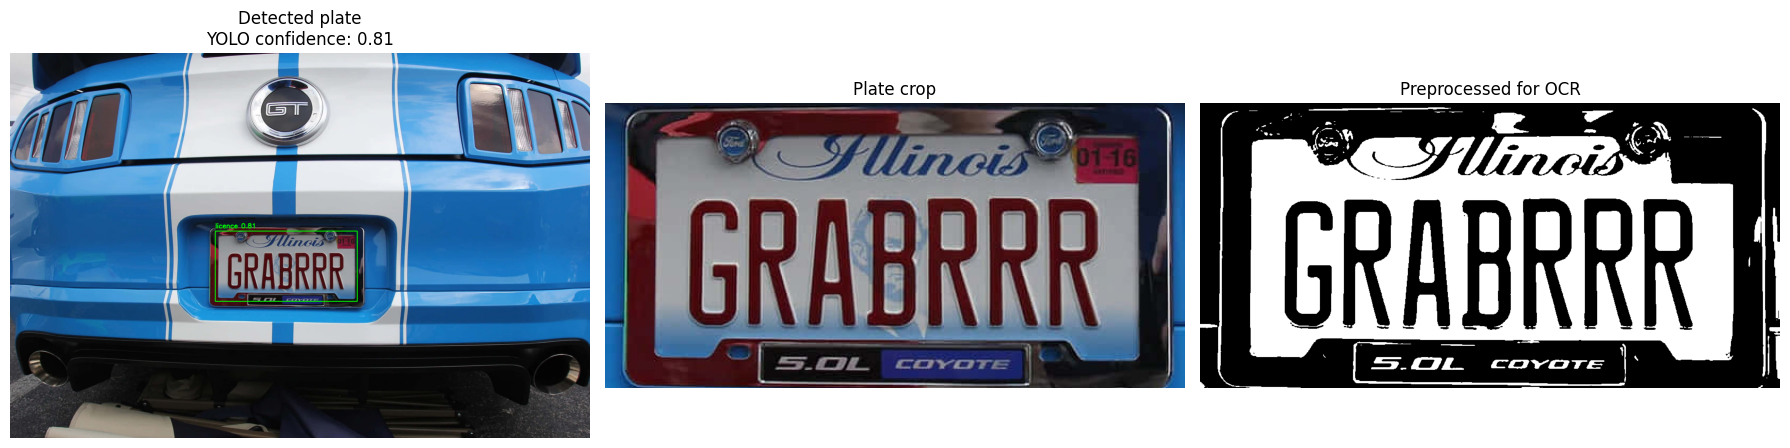

Raw OCR text     : )grlllinois GPAPPPR SOL coYOTE
Cleaned OCR text : GRLLLINOISGPAPPPRSOLCOYOTE
OCR confidence   : 0.471
OCR raw output   : [([[np.int32(339), np.int32(34)], [np.int32(800), np.int32(34)], [np.int32(800), np.int32(151)], [np.int32(339), np.int32(151)]], ')grlllinois', np.float64(0.07679046229745069)), ([[np.int32(134), np.int32(154)], [np.int32(965), np.int32(154)], [np.int32(965), np.int32(447)], [np.int32(134), np.int32(447)]], 'GPAPPPR', np.float64(0.6398405182932821)), ([[np.int32(321), np.int32(469)], [np.int32(497), np.int32(469)], [np.int32(497), np.int32(509)], [np.int32(321), np.int32(509)]], 'SOL', np.float64(0.9537760847023881)), ([[np.int32(544), np.int32(476)], [np.int32(760), np.int32(476)], [np.int32(760), np.int32(506)], [np.int32(544), np.int32(506)]], 'coYOTE', np.float64(0.21358719400737694))]


In [18]:
image_bgr = cv2.imread(str(IMAGE_PATH))
if image_bgr is None:
    raise FileNotFoundError(f"Could not read image: {IMAGE_PATH}")

best_box, best_score, raw_results = detect_best_plate(image_bgr, model, conf=0.25)

if best_box is None:
    print("No plate detected.")
else:
    detected_img = draw_detection(image_bgr, best_box, best_score)
    plate_crop_bgr, padded_box = crop_plate(image_bgr, best_box, pad_ratio=0.08)

    if plate_crop_bgr is None or plate_crop_bgr.size == 0:
        print("Detected box but crop is empty.")
    else:
        processed_plate = preprocess_plate_for_ocr(plate_crop_bgr)
        raw_text, ocr_conf, cleaned_text, ocr_results = run_ocr(processed_plate, reader)

        detected_img_rgb = cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB)
        plate_crop_rgb = cv2.cvtColor(plate_crop_bgr, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(18, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(detected_img_rgb)
        plt.title(f"Detected plate\nYOLO confidence: {best_score:.2f}")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(plate_crop_rgb)
        plt.title("Plate crop")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(processed_plate, cmap="gray")
        plt.title("Preprocessed for OCR")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        print("Raw OCR text     :", raw_text)
        print("Cleaned OCR text :", cleaned_text)
        print("OCR confidence   :", round(ocr_conf, 4))
        print("OCR raw output   :", ocr_results)


In [19]:
def detect_and_read_plate(
    image_path,
    model,
    reader,
    det_conf=0.25,
    pad_ratio=0.08,
    show=True
):
    image_path = Path(image_path)
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    best_box, best_score, _ = detect_best_plate(image_bgr, model, conf=det_conf)

    if best_box is None:
        return {
            "detected": False,
            "yolo_confidence": 0.0,
            "raw_text": "",
            "cleaned_text": "",
            "ocr_confidence": 0.0,
            "box": None
        }

    detected_img = draw_detection(image_bgr, best_box, best_score)
    plate_crop_bgr, padded_box = crop_plate(image_bgr, best_box, pad_ratio=pad_ratio)

    if plate_crop_bgr is None or plate_crop_bgr.size == 0:
        return {
            "detected": True,
            "yolo_confidence": best_score,
            "raw_text": "",
            "cleaned_text": "",
            "ocr_confidence": 0.0,
            "box": padded_box
        }

    processed_plate = preprocess_plate_for_ocr(plate_crop_bgr)
    raw_text, ocr_conf, cleaned_text, ocr_results = run_ocr(processed_plate, reader)

    if show:
        detected_img_rgb = cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB)
        plate_crop_rgb = cv2.cvtColor(plate_crop_bgr, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(18, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(detected_img_rgb)
        plt.title(f"Detected plate\nYOLO confidence: {best_score:.2f}")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(plate_crop_rgb)
        plt.title("Plate crop")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(processed_plate, cmap="gray")
        plt.title(f"OCR: {cleaned_text}\nOCR confidence: {ocr_conf:.2f}")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    return {
        "detected": True,
        "yolo_confidence": best_score,
        "raw_text": raw_text,
        "cleaned_text": cleaned_text,
        "ocr_confidence": ocr_conf,
        "box": padded_box,
        "ocr_raw_results": ocr_results
    }


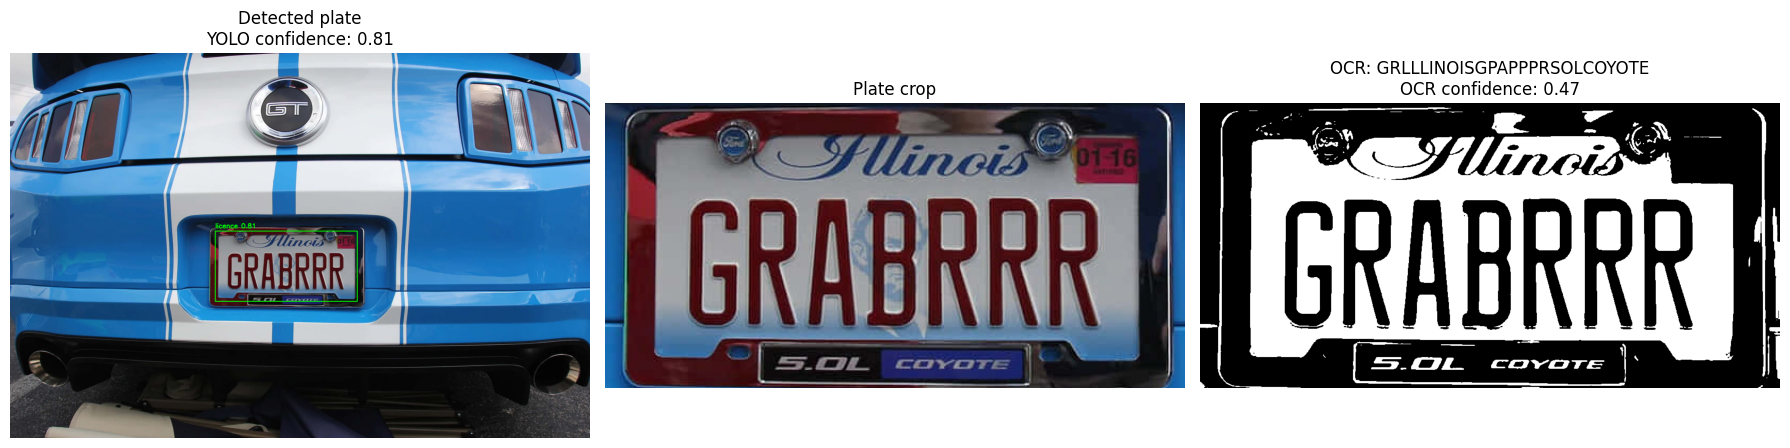

{'detected': True, 'yolo_confidence': 0.8083525896072388, 'raw_text': ')grlllinois GPAPPPR SOL coYOTE', 'cleaned_text': 'GRLLLINOISGPAPPPRSOLCOYOTE', 'ocr_confidence': 0.4709985648251245, 'box': (642, 573, 1186, 841), 'ocr_raw_results': [([[np.int32(339), np.int32(34)], [np.int32(800), np.int32(34)], [np.int32(800), np.int32(151)], [np.int32(339), np.int32(151)]], ')grlllinois', np.float64(0.07679046229745069)), ([[np.int32(134), np.int32(154)], [np.int32(965), np.int32(154)], [np.int32(965), np.int32(447)], [np.int32(134), np.int32(447)]], 'GPAPPPR', np.float64(0.6398405182932821)), ([[np.int32(321), np.int32(469)], [np.int32(497), np.int32(469)], [np.int32(497), np.int32(509)], [np.int32(321), np.int32(509)]], 'SOL', np.float64(0.9537760847023881)), ([[np.int32(544), np.int32(476)], [np.int32(760), np.int32(476)], [np.int32(760), np.int32(506)], [np.int32(544), np.int32(506)]], 'coYOTE', np.float64(0.21358719400737694))]}


In [20]:
result = detect_and_read_plate(
    image_path=IMAGE_PATH,
    model=model,
    reader=reader,
    det_conf=0.25,
    pad_ratio=0.08,
    show=True
)

print(result)


In [21]:
test_folder = PROJECT_ROOT / "test_images"

image_files = list(test_folder.glob("*.jpg")) + list(test_folder.glob("*.png")) + list(test_folder.glob("*.jpeg"))

all_results = []

for img_path in image_files:
    result = detect_and_read_plate(
        image_path=img_path,
        model=model,
        reader=reader,
        det_conf=0.25,
        pad_ratio=0.08,
        show=False
    )
    result["image_name"] = img_path.name
    all_results.append(result)

for r in all_results:
    print(r["image_name"], "->", r["cleaned_text"], "| detected:", r["detected"])
